In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

# Выводит список PIL.Image в виде сетки n_rows x n_cols.
def show_grid(images: list[Image], n_cols, n_rows, figscale=3.5, titles=None): # figscale - масштаб одной ячейки в дюймах, titles - список подписей под картинками
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(n_cols * figscale, n_rows * figscale),
                             squeeze=False)          # всегда 2D-массив осей

    for idx in range(n_rows * n_cols):
        row, col = divmod(idx, n_cols)
        ax = axes[row][col]
        ax.axis('off')                               # шкалы убираем всегда
        if idx < len(images):                        # есть картинка для этой ячейки
            ax.imshow(images[idx])
            if titles and idx < len(titles):
                ax.set_title(str(titles[idx]), fontsize=8)
        # иначе — ячейка остаётся пустой

    plt.tight_layout()
    plt.show()

## Определение цвета и прозрачности инвентрая

Для получения цвета и прозрачности проанализируем изображения ячеек с монотонным фоном до и после открытия инвентаря

In [ ]:
imgs = [
    (
        Image.open("/content/background1.png"),
        Image.open("/content/background1_with_inventory.png")
    ),
    (
        Image.open("/content/background2.png"),
        Image.open("/content/background2_with_inventory.png")
    ),
    (
        Image.open("/content/background3.png"),
        Image.open("/content/background3_with_inventory.png")
    ),
    (
        Image.open("/content/background4.png"),
        Image.open("/content/background4_with_inventory.png")
    )
]

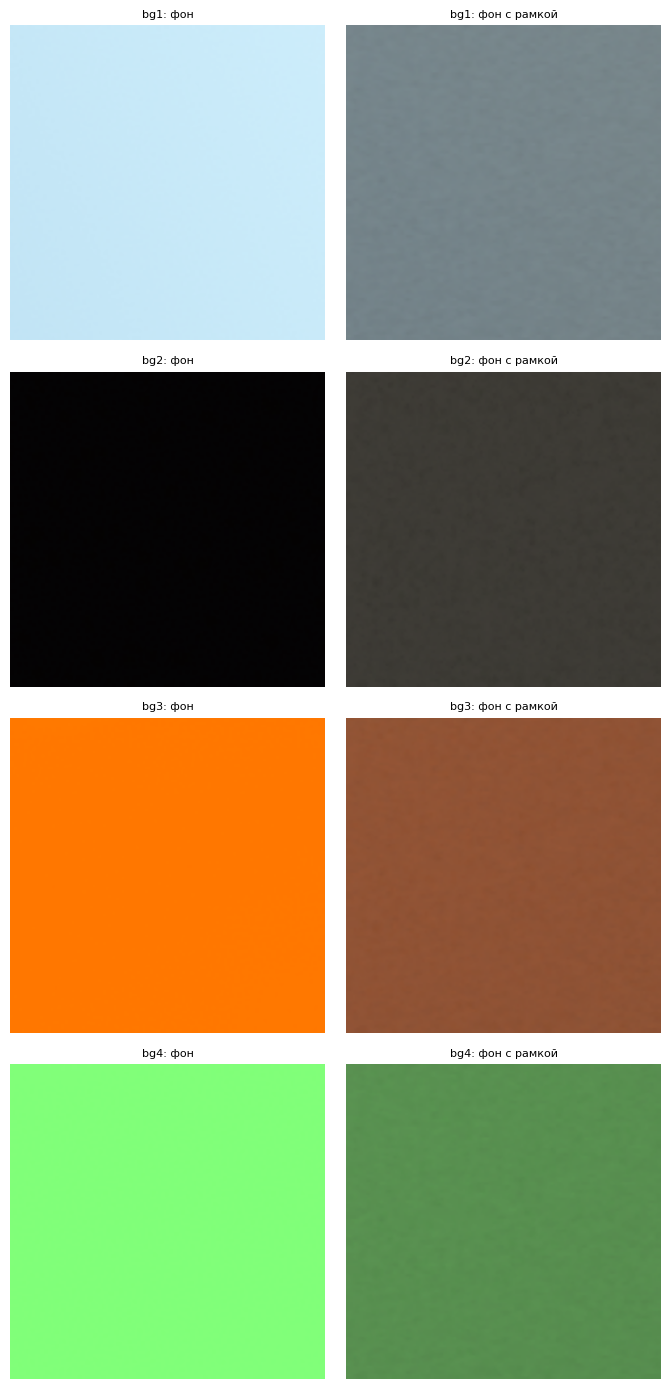

In [ ]:
grid_images = []
grid_titles = []
for i, imgs_pair in enumerate(imgs):
    grid_images += [imgs_pair[0], imgs_pair[1]]
    grid_titles += [f"bg{i+1}: фон", f"bg{i+1}: фон с рамкой"]

show_grid(
    images=grid_images,
    n_cols=2,
    n_rows=4,
    titles=grid_titles,
)

Для нахождения неизвестных параметров воспользуемся формулой альфа-композиции:

${O = α · C + (1−α) · B}$

- $B$ — фон
- $O$ — фон + инвентарь
- $C$ — цвет инвентаря
- $α$ — прозрачность инвентаря

In [ ]:
import numpy as np

def srgb_to_lin(c):
    c = c / 255.0
    return np.where(c <= 0.04045, c / 12.92, ((c + 0.055) / 1.055) ** 2.4)

def lin_to_srgb(c):
    c = np.where(c <= 0.0031308, c * 12.92, 1.055 * c ** (1 / 2.4) - 0.055)
    return c * 255.0

# Определяет alpha и цвет рамки инвентаря для композитинга в ЛИНЕЙНОМ свете
def solve_frame(imgs):
    B, O = [], []
    for closed_img, opened_img in imgs:
        b = np.asarray(closed_img.convert('RGB'), float)
        o = np.asarray(opened_img.convert('RGB'), float)
        B.append(b.reshape(-1, 3).mean(0))
        O.append(o.reshape(-1, 3).mean(0))
    B, O = np.array(B), np.array(O)

    # переходим в линейный свет — именно там смешение линейно
    Bl, Ol = srgb_to_lin(B), srgb_to_lin(O)

    # поканально: Ol = (1-alpha)*Bl + alpha*C_lin  -> регрессия по фонам
    alphas, colors_lin = [], []
    for ch in range(3):
        slope, intercept = np.polyfit(Bl[:, ch], Ol[:, ch], 1)
        a = 1 - slope
        alphas.append(a)
        colors_lin.append(intercept / a)

    alpha = float(np.mean(alphas))
    color_lin = np.array(colors_lin)
    color_srgb = np.clip(lin_to_srgb(color_lin), 0, 255)
    return alpha, color_srgb

In [ ]:
alpha, color_srgb = solve_frame(imgs)
print(f"alpha = {alpha:.4f}")
print(f"цвет рамки (sRGB) = ({color_srgb[0]:.0f}, {color_srgb[1]:.0f}, {color_srgb[2]:.0f})")

alpha = 0.7673
цвет рамки (sRGB) = (70, 67, 61)


## Функция для наложения рамки на фон

In [ ]:
def srgb_to_lin(c):
    c = np.asarray(c, float) / 255.0
    return np.where(c <= 0.04045, c / 12.92, ((c + 0.055) / 1.055) ** 2.4)

def lin_to_srgb(c):
    c = np.where(c <= 0.0031308, c * 12.92, 1.055 * c ** (1 / 2.4) - 0.055)
    return (c * 255.0).clip(0, 255).astype('uint8')

ALPHA = 0.7673
FRAME_COLOR_SRGB = (70, 67, 61)

# Накладывает полупрозрачную рамку инвентаря на переданное изображение
def apply_frame(background, alpha=ALPHA, color_srgb=FRAME_COLOR_SRGB, region=None):
    bg = np.asarray(background.convert('RGB') if isinstance(background, Image.Image)
                    else background, float)
    color_lin = srgb_to_lin(color_srgb)
    out_lin = srgb_to_lin(bg)

    if region is None:
        x1, y1, x2, y2 = 0, 0, bg.shape[1], bg.shape[0]
    else:
        x1, y1, x2, y2 = region

    zone = out_lin[y1:y2, x1:x2]
    out_lin[y1:y2, x1:x2] = alpha * color_lin + (1 - alpha) * zone   # смешение в линейном свете

    return Image.fromarray(lin_to_srgb(out_lin))

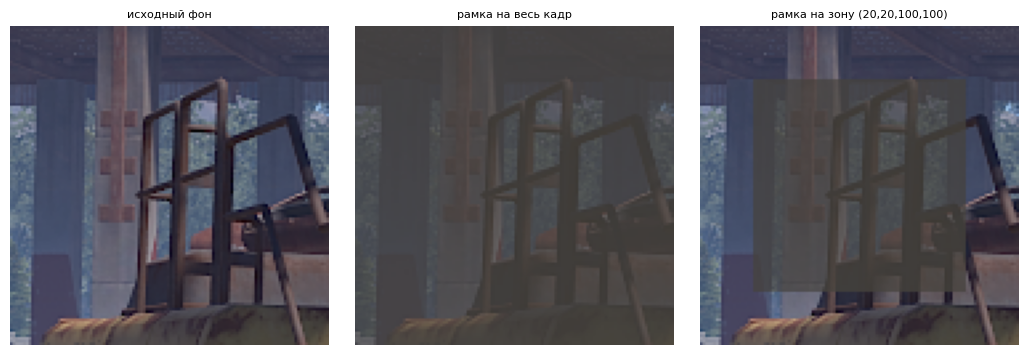

In [ ]:
# пример наложения затемнения ячейки на фон
background_test = Image.open("/content/backgrond_test.png")

background_framed_full   = apply_frame(background_test)
background_framed_region = apply_frame(background_test, region=(20, 20, 100, 100))

show_grid(
    images=[background_test, background_framed_full, background_framed_region],
    n_cols=3,
    n_rows=1,
    titles=["исходный фон", "рамка на весь кадр", "рамка на зону (20,20,100,100)"],
)

## Элементы ячеек инвентаря

Ячейка инвентаря имеет следующие элементы:

1) Сам предмет (смещённый относительно центра и краёв ячейки)
2) Полоска прочности предмета (красный - необратимая поломка, прозрачный - обратимая поломка, зелёный - активная прочность предмета)
3) Ячейки модификаторов (тусклая ячейка - неактивный модификатор, яркая ячейка - активный модификатор)
4) Текст (количество предметов / иная числовая характеристика)



In [ ]:
chest_interface =[
    {
        'cell_cord': (1677, 233, 1792, 348),
        'item_cord': (1685, 237, 1784, 332),
        'durability_col_cord': (1677, 233, 1684, 348),
        'modifier_cords': [(1689, 241, 1696, 248), (1689, 251, 1696, 258), (1689, 261, 1696, 268), (1689, 271, 1696, 278)],
        'text_cord': (1711, 320, 1785, 344),
        # 'scale': 1.00,
        # 'width': 2560,
        # 'height': 1440
    },
    {
        'cell_cord': (1598, 474, 1689, 566),
        'item_cord': (1604, 478, 1683, 553),
        'durability_col_cord': (1598, 474, 1603, 566),
        'modifier_cords': [(1607, 481, 1613, 486), (1607, 489, 1613, 494), (1607, 497, 1613, 502), (1607, 505, 1613, 510)],
        'text_cord': (1626, 544, 1684, 564),
        # 'scale': 0.80,
        # 'width': 2560,
        # 'height': 1440
    },
    {
        'cell_cord': (1538, 655, 1612, 730),
        'item_cord': (1543, 658, 1607, 719),
        'durability_col_cord': (1538, 655, 1542, 730),
        'modifier_cords': [(1546, 661, 1550, 665), (1546, 667, 1550, 671), (1546, 674, 1550, 678), (1546, 680, 1550, 684)],
        'text_cord': (1561, 712, 1609, 728),
        # 'scale': 0.65,
        # 'width': 2560,
        # 'height': 1440
    },
    {
        'cell_cord': (1478, 836, 1535, 893),
        'item_cord': (1482, 838, 1531, 885),
        'durability_col_cord': (1478, 836, 1481, 893),
        'modifier_cords': [(1484, 840, 1487, 843), (1484, 845, 1487, 848), (1484, 850, 1487, 853), (1484, 855, 1487, 858)],
        'text_cord': (1496, 880, 1533, 893),
        # 'scale': 0.50,
        # 'width': 2560,
        # 'height': 1440
    },
    {
        'cell_cord': (1258, 175, 1344, 261),
        'item_cord': (1264, 178, 1338, 249),
        'durability_col_cord': (1258, 175, 1263, 261),
        'modifier_cords': [(1267, 181, 1272, 186), (1267, 188, 1272, 193), (1267, 196, 1272, 201), (1267, 203, 1272, 208)],
        'text_cord': (1281, 240, 1339, 259),
        # 'scale': 1.00,
        # 'width': 1920,
        # 'height': 1080
    },
    {
        'cell_cord': (1198, 356, 1267, 424),
        'item_cord': (1203, 358, 1262, 415),
        'durability_col_cord': (1198, 356, 1202, 424),
        'modifier_cords': [(1205, 361, 1209, 364), (1205, 367, 1209, 370), (1205, 373, 1209, 376), (1205, 379, 1209, 382)],
        'text_cord': (1221, 408, 1264, 423),
        # 'scale': 0.80,
        # 'width': 1920,
        # 'height': 1080
    },
    {
        'cell_cord': (1154, 492, 1209, 547),
        'item_cord': (1157, 494, 1205, 539),
        'durability_col_cord': (1154, 492, 1156, 547),
        'modifier_cords': [(1159, 495, 1162, 498), (1159, 500, 1162, 503), (1159, 505, 1162, 508), (1159, 510, 1162, 513)],
        'text_cord': (1170, 535, 1206, 546),
        # 'scale': 0.65,
        # 'width': 1920,
        # 'height': 1080
    },
    {
        'cell_cord': (1109, 627, 1151, 670),
        'item_cord': (1112, 629, 1148, 664),
        'durability_col_cord': (1109, 627, 1111, 670),
        'modifier_cords': [(1113, 630, 1115, 632), (1113, 634, 1115, 636), (1113, 638, 1115, 640), (1113, 642, 1115, 644)],
        'text_cord': (1123, 661, 1149, 669),
        # 'scale': 0.50,
        # 'width': 1920,
        # 'height': 1080
    }
]

In [ ]:
def cord_without_bias(cord, x0, y0):
    return (cord[0] - x0, cord[1] - y0, cord[2] - x0, cord[3] - y0)

# Координаты внутренних элементов от начала отсчёта ячейки
cell_info = []

for info in chest_interface:
    x0, y0, x1, y1 = info['cell_cord']
    cell_info.append({
        "cell_width": x1 - x0,
        "cell_height": y1 - y0,
        "item_cord": cord_without_bias(info['item_cord'], x0, y0),
        "durability_col_cord": cord_without_bias(info['durability_col_cord'], x0, y0),
        "modifier_cords": [cord_without_bias(cord, x0, y0) for cord in info['modifier_cords']],
        "text_cord": cord_without_bias(info['text_cord'], x0, y0),
    })

cell_info

[{'cell_width': 115,
  'cell_height': 115,
  'item_cord': (8, 4, 107, 99),
  'durability_col_cord': (0, 0, 7, 115),
  'modifier_cords': [(12, 8, 19, 15),
   (12, 18, 19, 25),
   (12, 28, 19, 35),
   (12, 38, 19, 45)],
  'text_cord': (34, 87, 108, 111)},
 {'cell_width': 91,
  'cell_height': 92,
  'item_cord': (6, 4, 85, 79),
  'durability_col_cord': (0, 0, 5, 92),
  'modifier_cords': [(9, 7, 15, 12),
   (9, 15, 15, 20),
   (9, 23, 15, 28),
   (9, 31, 15, 36)],
  'text_cord': (28, 70, 86, 90)},
 {'cell_width': 74,
  'cell_height': 75,
  'item_cord': (5, 3, 69, 64),
  'durability_col_cord': (0, 0, 4, 75),
  'modifier_cords': [(8, 6, 12, 10),
   (8, 12, 12, 16),
   (8, 19, 12, 23),
   (8, 25, 12, 29)],
  'text_cord': (23, 57, 71, 73)},
 {'cell_width': 57,
  'cell_height': 57,
  'item_cord': (4, 2, 53, 49),
  'durability_col_cord': (0, 0, 3, 57),
  'modifier_cords': [(6, 4, 9, 7),
   (6, 9, 9, 12),
   (6, 14, 9, 17),
   (6, 19, 9, 22)],
  'text_cord': (18, 44, 55, 57)},
 {'cell_width': 86,


## Определение координат расположения элементов ячейки

Для аугментации не нужно соблюдать высокую точность координат (по сравнению с детектированием). Будем расчитывать позиционирование элементов в процентом соотношении от размера ячейки инвентаря

In [ ]:

# Расчёт долей для определения расположения элементов в зависимости от размеров ячейки
def compute_fractions(cell_info):

    # переводит пиксельный прямоугольник в доли ячейки
    def frac(W, H, box):
        x0, y0, x1, y1 = box
        return np.array([x0/W, y0/H, x1/W, y1/H])

    item, dur, txt = [], [], []
    mods = [[], [], [], []]   # доли для каждого из 4 модификаторов отдельно

    for c in cell_info:
        W, H = c['cell_width'], c['cell_height']
        item.append(frac(W, H, c['item_cord']))
        dur.append(frac(W, H, c['durability_col_cord']))
        txt.append(frac(W, H, c['text_cord']))
        for i, m in enumerate(c['modifier_cords']):
            mods[i].append(frac(W, H, m))

    # усредняем доли по всем конфигурациям
    item = np.mean(item, axis=0)
    dur = np.mean(dur, axis=0)
    txt = np.mean(txt, axis=0)
    mods = [np.mean(m, axis=0) for m in mods]   # 4 средних прямоугольника

    # модификаторы: берём первый + средний шаг вниз между соседними
    mod_x  = (mods[0][0], mods[0][2])           # fx0, fx1 (одинаковы у всех)
    mod_y0 = (mods[0][1], mods[0][3])           # fy0, fy1 первого
    steps  = [mods[i+1][1] - mods[i][1] for i in range(3)]  # шаги между модификаторами
    step_y = np.mean(steps)

    return {
        'item':            tuple(round(v, 3) for v in item),
        'durability':      tuple(round(v, 3) for v in dur),
        'text':            tuple(round(v, 3) for v in txt),
        'modifier_x':      tuple(round(v, 3) for v in mod_x),
        'modifier_y0':     tuple(round(v, 3) for v in mod_y0),
        'modifier_step_y': round(float(step_y), 3),
        'modifier_count':  len(mods),
    }

cell_elements_fractions = compute_fractions(cell_info)
cell_elements_fractions

{'item': (np.float64(0.068),
  np.float64(0.038),
  np.float64(0.93),
  np.float64(0.859)),
 'durability': (np.float64(0.0),
  np.float64(0.0),
  np.float64(0.053),
  np.float64(1.0)),
 'text': (np.float64(0.307),
  np.float64(0.768),
  np.float64(0.951),
  np.float64(0.98)),
 'modifier_x': (np.float64(0.101), np.float64(0.158)),
 'modifier_y0': (np.float64(0.07), np.float64(0.123)),
 'modifier_step_y': 0.088,
 'modifier_count': 4}

In [ ]:
CELL_ELEMENTS_FRACTIONS = {
    'item': (0.068, 0.038, 0.93, 0.859),
    'durability': (0.0, 0.0, 0.053, 1.0),
    'text': (0.307, 0.768, 0.951, 0.98),
    'modifier_x': (0.101, 0.158),
    'modifier_y0': (0.07, 0.123),
    'modifier_step_y': 0.088,
    'modifier_count': 4
}

# Возвращаем координаты элементов ячейки ОТНОСИТЕЛЬНО левого верхнего угла самой ячейки
def element_boxes(cell_width, cell_height):
    W, H = cell_width, cell_height

    def px(frac):
        fx0, fy0, fx1, fy1 = frac
        return (round(fx0*W), round(fy0*H), round(fx1*W), round(fy1*H))

    out = {
        'item':       px(CELL_ELEMENTS_FRACTIONS['item']),
        'durability': px(CELL_ELEMENTS_FRACTIONS['durability']),
        'text':       px(CELL_ELEMENTS_FRACTIONS['text']),
        'modifiers':  [],
    }

    mx0, mx1 = CELL_ELEMENTS_FRACTIONS['modifier_x']    # левый/правый край (общие)
    my0, my1 = CELL_ELEMENTS_FRACTIONS['modifier_y0']   # верх/низ первого модификатора
    for i in range(CELL_ELEMENTS_FRACTIONS['modifier_count']):
        dy = i * CELL_ELEMENTS_FRACTIONS['modifier_step_y']    # сдвиг вниз для i-го
        out['modifiers'].append((
            round(mx0*W),         round((my0 + dy)*H),
            round(mx1*W),         round((my1 + dy)*H),
        ))
    return out

In [ ]:
# пример получения координат элементов
width, height = background_framed_full.width, background_framed_full.height
print(f"{width}x{height}\n")

elems_cord = element_boxes(width, height)
elems_cord

120x120



{'item': (8, 5, 112, 103),
 'durability': (0, 0, 6, 120),
 'text': (37, 92, 114, 118),
 'modifiers': [(12, 8, 19, 15),
  (12, 19, 19, 25),
  (12, 30, 19, 36),
  (12, 40, 19, 46)]}

## Размещение элементов внутри ячейки


In [ ]:
ELEMENTS_FONT_DATA = {
    'durability_active_color': '#718a43',
    'durability_spent_color': '#955847',
    'modifier_active_color': '#e4e4e3',
    'modifier_empty_color': '#81807f',
    'text_color': '#a1a09f',
    'text_approximate_font': 'RobotoCondensed-Bold.ttf'
}

### 1) Расположение предмета внутри ячейки

In [ ]:

# Накладывает предмет в заданный контейнер внутри фона
def place_item(background_img, item_img, container_cords, keep_aspect=False, resample=Image.LANCZOS): # keep_aspect - (True) вписать в контейнер с сохранением пропорций или (False) расстянуть ровно под контейнер
    it = Image.open(item_img) if isinstance(item_img, str) else item_img
    it = it.convert('RGBA')

    x0, y0, x1, y1 = container_cords
    cw, ch = x1 - x0, y1 - y0

    if keep_aspect:
        iw, ih = it.size
        scale = min(cw/iw, ch/ih)                    # вписываем по меньшей стороне
        nw, nh = max(1, round(iw*scale)), max(1, round(ih*scale))
        it = it.resize((nw, nh), resample)
        px = x0 + (cw - nw)//2                        # центрируем в контейнере
        py = y0 + (ch - nh)//2
    else:
        it = it.resize((cw, ch), resample)           # растягиваем под контейнер
        px, py = x0, y0

    background_img.paste(it, (px, py), it)   # третий аргумент — маска (альфа предмета)

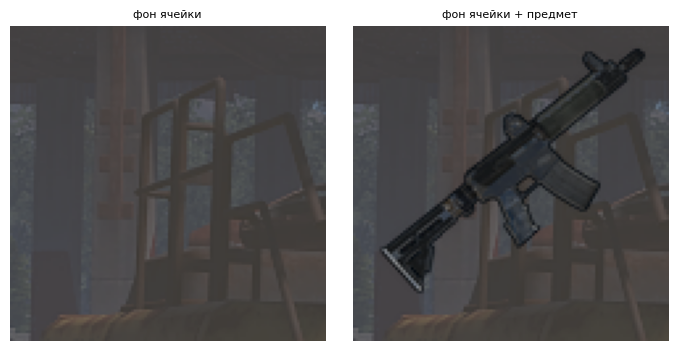

In [ ]:
# пример
img_aug = background_framed_full.copy()

item_test = Image.open("/content/rifle.lr300.png")
place_item(img_aug, item_test, elems_cord["item"])

show_grid(
    images=[background_framed_full, img_aug],
    n_cols=2,
    n_rows=1,
    titles=["фон ячейки", "фон ячейки + предмет"]
)

### 2) Отрисовка прочности предмета

Пустая полоска прочности имеет цвет и прозрачность. Для определения этих параметров воспользуемся тем же способом, что и при определении цвета рамки инвентаря

In [ ]:
imgs = [
    (
        Image.open("/content/background5_with_inventory.png"),
        Image.open("/content/background5_with_durability.png")
    ),
    (
        Image.open("/content/background6_with_inventory.png"),
        Image.open("/content/background6_with_durability.png")
    ),
    (
        Image.open("/content/background7_with_inventory.png"),
        Image.open("/content/background7_with_durability.png")
    ),
    (
        Image.open("/content/background8_with_inventory.png"),
        Image.open("/content/background8_with_durability.png")
    ),
    (
        Image.open("/content/background9_with_inventory.png"),
        Image.open("/content/background9_with_durability.png")
    ),
    (
        Image.open("/content/background10_with_inventory.png"),
        Image.open("/content/background10_with_durability.png")
    )
]

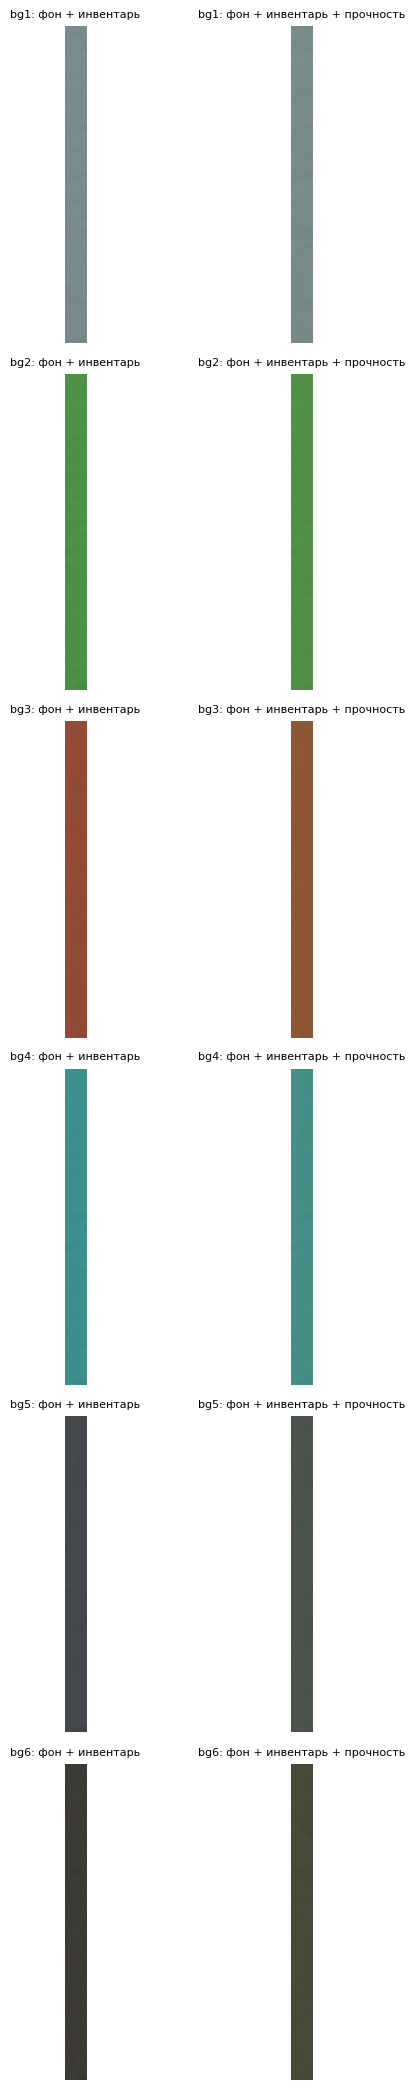

In [ ]:
grid_images = []
grid_titles = []
for i, imgs_pair in enumerate(imgs):
    grid_images += [imgs_pair[0], imgs_pair[1]]
    grid_titles += [f"bg{i+1}: фон + инвентарь", f"bg{i+1}: фон + инвентарь + прочность"]

show_grid(
    images=grid_images,
    n_cols=2,
    n_rows=6,
    titles=grid_titles,
)

In [ ]:
alpha, color_srgb = solve_frame(imgs)
print(f"alpha = {alpha:.4f}")
print(f"цвет полоски прочности (sRGB) = ({color_srgb[0]:.0f}, {color_srgb[1]:.0f}, {color_srgb[2]:.0f})")

alpha = 0.1268
цвет полоски прочности (sRGB) = (112, 137, 67)


In [ ]:
ELEMENTS_FONT_DATA['durability_empty_alpha'] = 0.1268
ELEMENTS_FONT_DATA['durability_empty_color_srgb'] = (112, 137, 67)

In [ ]:
from PIL import ImageDraw

# Сгенерировать пропорции двух случайных сечений, которые делят столбец прочности на 3 части
def get_durability_proportions(min_frac=0.0):  # min_frac - минимальная доля высоты, которую получит каждая часть контейнера
    a = random.uniform(min_frac, 1 - min_frac)
    b = random.uniform(min_frac, 1 - min_frac)
    spent_frac, active_frac = sorted((a, b))
    return spent_frac, active_frac

# Рисует вертикальный контейнер прочности, разделённый на 3 части (spent, null, active)
def draw_durability(image, box, spent_frac=0.33, active_frac=0.33):
    x0, y0, x1, y1 = box
    H = y1 - y0
    if H <= 0 or x1 <= x0:
        return image

    y_red_end   = y0 + round(spent_frac * H)        # докуда красный сверху
    y_green_top = y0 + round(active_frac * H)        # откуда зелёный снизу

    draw = ImageDraw.Draw(image)
    # верх — красный (spent), непрозрачный
    if y_red_end > y0:
        draw.rectangle((x0, y0, x1, y_red_end),
                       fill=ELEMENTS_FONT_DATA['durability_spent_color'])
    # низ — зелёный (active), непрозрачный
    if y1 > y_green_top:
        draw.rectangle((x0, y_green_top, x1, y1),
                       fill=ELEMENTS_FONT_DATA['durability_active_color'])
    # середина — полупрозрачная (empty)
    if y_green_top > y_red_end:
        mid_region = (x0, y_red_end, x1+1, y_green_top)
        blended = apply_frame(
            image,
            ELEMENTS_FONT_DATA['durability_empty_alpha'],
            ELEMENTS_FONT_DATA['durability_empty_color_srgb'],
            region=mid_region
        )
        mid = blended.crop(mid_region)        # вырезаем только середину
        image.paste(mid, (x0, y_red_end))     # вставляем строго в её границы
    return image

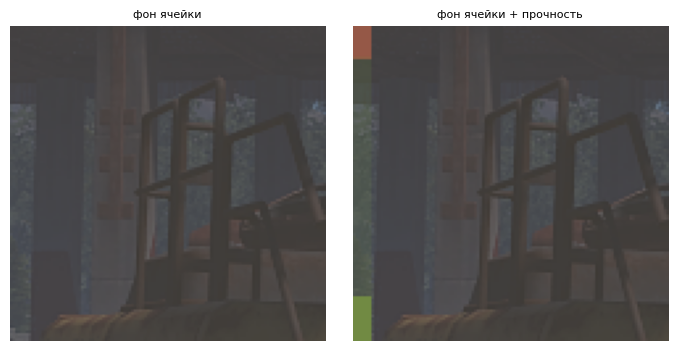

In [ ]:
# пример
img_aug = background_framed_full.copy()

spent_frac, active_frac = get_durability_proportions()
draw_durability(img_aug, elems_cord["durability"], spent_frac, active_frac)

show_grid(
    images=[background_framed_full, img_aug],
    n_cols=2,
    n_rows=1,
    titles=["фон ячейки", "фон ячейки + прочность"]
)

### 3) Отрисовка модификаторов предмета

In [ ]:
# Количество модификаторов для отображения
def get_modifiers_count(max_count, min_count=0): # min_count - минимальное количество контейнеров для отрисовки
    show_count = random.randint(min_count, max_count) # сколько модификаторов вообще показать
    active_count = random.randint(0, show_count) # сколько из показанных заполнено
    return show_count, active_count

# Рисует контейнеры модификаторов по координатам из modifier_boxes
def draw_modifiers(image, modifier_boxes_cords, show_count=3, active_count=1):
    draw = ImageDraw.Draw(image)
    for i, box in enumerate(modifier_boxes_cords[:show_count]):
        color = ELEMENTS_FONT_DATA['modifier_active_color'] if i < active_count else ELEMENTS_FONT_DATA['modifier_empty_color']   # первые active_count — яркие, дальше тусклые
        draw.rectangle(box, fill=color)
    return image

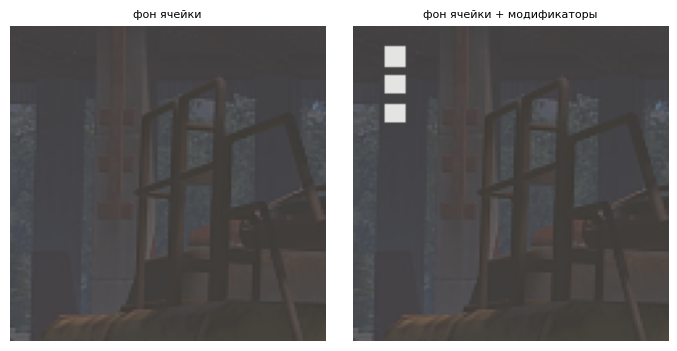

In [ ]:
# пример
img_aug = background_framed_full.copy()

show_count, active_count = get_modifiers_count(len(elems_cord["modifiers"]))
draw_modifiers(img_aug, elems_cord["modifiers"], show_count, active_count)

show_grid(
    images=[background_framed_full, img_aug],
    n_cols=2,
    n_rows=1,
    titles=["фон ячейки", "фон ячейки + модификаторы"]
)

### 4) Отрисовка текста

In [ ]:
import string
from PIL import ImageFont

# Случайная строка из букв и цифр
def get_random_text(min_symblos=1, max_symbols=6):
    alphabet = string.ascii_letters + string.digits
    text = ''.join(random.choice(alphabet)
                   for _ in range(random.randint(min_symblos, max_symbols)))
    return text

# Рисует текст внутри text_box, вписывая его в рамку.
def draw_text(image: Image, text_box_cords, text="x1.000"): # min_symblos, max_symbols - лимит по количеству символов в строке
    x0, y0, x1, y1 = text_box_cords
    box_w, box_h = x1 - x0, y1 - y0

    draw = ImageDraw.Draw(image)

    def make_font(size):
        return ImageFont.truetype(ELEMENTS_FONT_DATA['text_approximate_font'], size)

    def text_size(font):
        l, t, r, b = draw.textbbox((0, 0), text, font=font)
        return r - l, b - t, l, t

    # 2) бинарный поиск максимального размера, влезающего в рамку по ширине И высоте
    lo, hi, best = 4, max(box_h * 2, 8), 4
    while lo <= hi:
        mid = (lo + hi) // 2
        tw, th, _, _ = text_size(make_font(mid))
        if tw <= box_w and th <= box_h:
            best = mid; lo = mid + 1
        else:
            hi = mid - 1

    # 3) слегка рандомизируем размер вниз от максимума
    size = random.randint(max(4, int(best * 0.7)), best)
    font = make_font(size)

    # 4) прижимаем к правому краю, центрируем по вертикали
    tw, th, off_l, off_t = text_size(font)
    px = x1 - tw - off_l
    py = y0 + (box_h - th) // 2 - off_t
    draw.text((px, py), text, font=font, fill=ELEMENTS_FONT_DATA['text_color'])

    return image

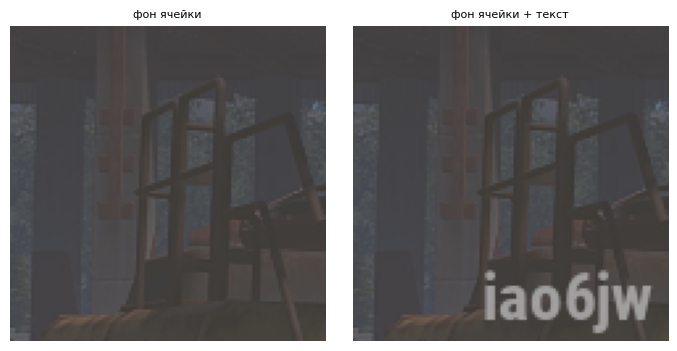

In [ ]:
# пример
img_aug = background_framed_full.copy()

text = get_random_text()
draw_text(img_aug, elems_cord["text"], text)

show_grid(
    images=[background_framed_full, img_aug],
    n_cols=2,
    n_rows=1,
    titles=["фон ячейки", "фон ячейки + текст"]
)

## Полный pipeline обработки изображения

In [ ]:
# Генерирует случайный размер ячейки
def random_cell_size(min_side=40, max_side=140):
    base = random.randint(min_side, max_side)
    bias = random.randint(-1, 1)
    return (base, base + bias)

# Вырезает случайную область размером (width, height) из изображения.
def random_crop(image, width, height):
    W, H = image.size
    if width > W or height > H:
        raise ValueError(f"область {width}x{height} больше изображения {W}x{H}")

    # случайный левый-верхний угол так, чтобы область поместилась целиком
    x0 = random.randint(0, W - width)
    y0 = random.randint(0, H - height)

    return image.crop((x0, y0, x0 + width, y0 + height))

In [ ]:
# --- применение аугментации ---

to_show = []
item_test = Image.open("/content/rifle.lr300.png")

# 1) Берём игровой фон
full_size_background = Image.open("/content/full_size_background.png")

# 2) Вырезаем случайную область под размер ячейки
cell_width, cell_height = random_cell_size()
cropped_background = random_crop(full_size_background, cell_width, cell_height)
to_show.append(cropped_background)

# 3) Накладываем фон инвентаря
aug_cell = apply_frame(cropped_background)
to_show.append(aug_cell.copy())

# 4) Вычисляем расположение элементво внутри ячейки
elems_cord = element_boxes(cell_width, cell_height)

# 5) Добавляем элементы внутрь ячейки
place_item(aug_cell, item_test, elems_cord["item"])
to_show.append(aug_cell.copy())

spent_frac, active_frac = get_durability_proportions()
draw_durability(aug_cell, elems_cord["durability"], spent_frac, active_frac)
to_show.append(aug_cell.copy())

show_count, active_count = get_modifiers_count(len(elems_cord["modifiers"]))
draw_modifiers(aug_cell, elems_cord["modifiers"], show_count, active_count)
to_show.append(aug_cell.copy())

text = get_random_text()
draw_text(aug_cell, elems_cord["text"], text)
to_show.append(aug_cell.copy())


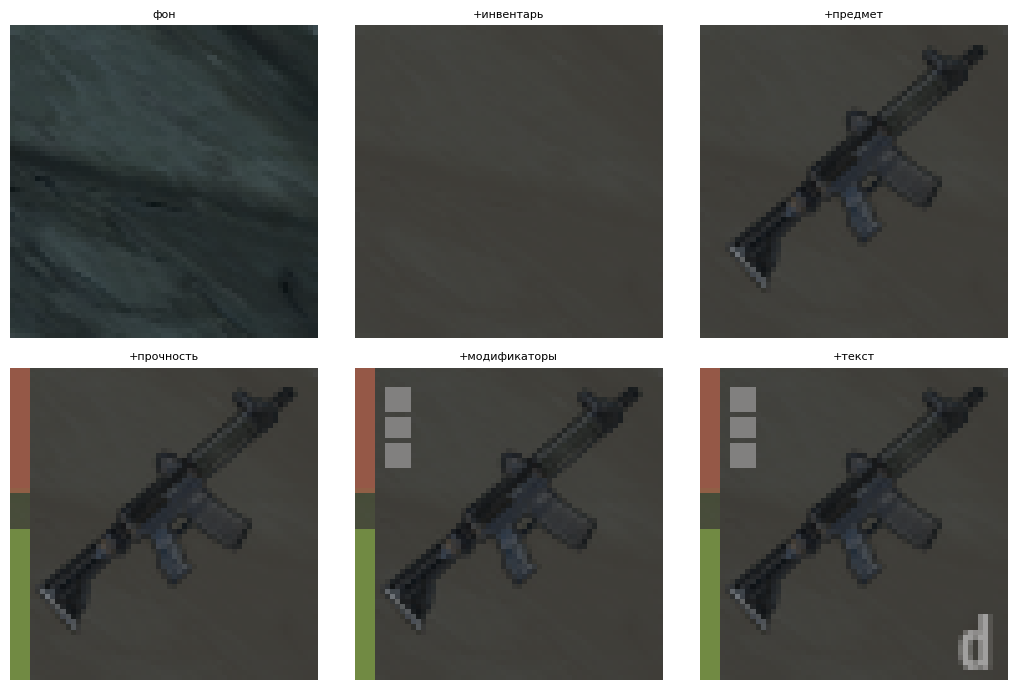

In [ ]:
show_grid(
    images=to_show,
    n_cols=3,
    n_rows=2,
    titles=["фон", "+инвентарь", "+предмет", "+прочность", "+модификаторы", "+текст"]
)

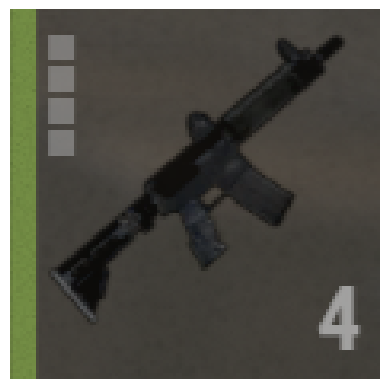

In [ ]:
# сравнение с реальной ячейкой
cell_real = Image.open("/content/lr300_real.png")

plt.imshow(cell_real)
plt.axis('off')
plt.show()